In [ ]:
import math
from collections import Counter


data = [
    ["Sunny",    "Hot",  "High",   "Weak",   "No"],
    ["Sunny",    "Hot",  "High",   "Strong", "No"],
    ["Overcast", "Hot",  "High",   "Weak",   "Yes"],
    ["Rain",     "Mild", "High",   "Weak",   "Yes"],
    ["Rain",     "Cool", "Normal", "Weak",   "Yes"],
    ["Rain",     "Cool", "Normal", "Strong", "No"],
    ["Overcast", "Cool", "Normal", "Strong", "Yes"],
    ["Sunny",    "Mild", "High",   "Weak",   "No"],
    ["Sunny",    "Cool", "Normal", "Weak",   "Yes"],
    ["Rain",     "Mild", "Normal", "Weak",   "Yes"],
    ["Sunny",    "Mild", "Normal", "Strong", "Yes"],
    ["Overcast", "Mild", "High",   "Strong", "Yes"],
    ["Overcast", "Hot",  "Normal", "Weak",   "Yes"],
    ["Rain",     "Mild", "High",   "Strong", "No"]
]

features = ["Outlook", "Temperature", "Humidity", "Wind"]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]
def entropy(labels):

    counts = Counter(labels)
    total = len(labels)

    ent = 0

    for count in counts.values():

        probability = count / total

        ent -= probability * math.log2(probability)

    return ent


def information_gain(X, y, feature_index):

   
    parent_entropy = entropy(y)

    
    values = set(row[feature_index] for row in X)

    weighted_entropy = 0

    for value in values:

        subset_y = []

        for i in range(len(X)):

            if X[i][feature_index] == value:
                subset_y.append(y[i])

    
        weight = len(subset_y) / len(y)

        subset_entropy = entropy(subset_y)

        weighted_entropy += weight * subset_entropy

    
    gain = parent_entropy - weighted_entropy

    return gain



def best_feature(X, y, feature_indices):

    best_gain = -1
    best_index = None

    for index in feature_indices:

        gain = information_gain(X, y, index)

        print(
            "Feature:",
            features[index],
            "Information Gain:",
            round(gain, 4)
        )

        if gain > best_gain:

            best_gain = gain
            best_index = index

    return best_index




def id3(X, y, feature_indices):


    if len(set(y)) == 1:

        return y[0]

   
    if len(feature_indices) == 0:

        return Counter(y).most_common(1)[0][0]

    best_index = best_feature(
        X,
        y,
        feature_indices
    )

    best_name = features[best_index]

    tree = {
        best_name: {}
    }
    values = set(
        row[best_index]
        for row in X
    )

    remaining_features = [
        index
        for index in feature_indices
        if index != best_index
    ]

  
    for value in values:

        subset_X = []
        subset_y = []

        for i in range(len(X)):

            if X[i][best_index] == value:

                subset_X.append(X[i])
                subset_y.append(y[i])

        subtree = id3(
            subset_X,
            subset_y,
            remaining_features
        )

        tree[best_name][value] = subtree

    return tree


print("\nBuilding Decision Tree...\n")

feature_indices = list(range(len(features)))

tree = id3(
    X,
    y,
    feature_indices
)


print("\nFinal Decision Tree:")
print(tree)


def predict(tree, sample):

  
    if not isinstance(tree, dict):

        return tree
   
    feature_name = list(tree.keys())[0]

    feature_index = features.index(feature_name)

    value = sample[feature_index]

    subtree = tree[feature_name][value]
    return predict(subtree, sample)


sample = [
    "Sunny",
    "Cool",
    "High",
    "Strong"
]

result = predict(tree, sample)

print("\nNew Sample:")
print(sample)

print("Prediction:", result)


Building Decision Tree...

Feature: Outlook Information Gain: 0.2467
Feature: Temperature Information Gain: 0.0292
Feature: Humidity Information Gain: 0.1518
Feature: Wind Information Gain: 0.0481
Feature: Temperature Information Gain: 0.571
Feature: Humidity Information Gain: 0.971
Feature: Wind Information Gain: 0.02
Feature: Temperature Information Gain: 0.02
Feature: Humidity Information Gain: 0.02
Feature: Wind Information Gain: 0.971

Final Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'Normal': 'Yes', 'High': 'No'}}, 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}, 'Overcast': 'Yes'}}

New Sample:
['Sunny', 'Cool', 'High', 'Strong']
Prediction: No



Building Decision Tree...

Feature: Outlook Information Gain: 0.2467
Feature: Temperature Information Gain: 0.0292
Feature: Humidity Information Gain: 0.1518
Feature: Wind Information Gain: 0.0481
Feature: Temperature Information Gain: 0.571
Feature: Humidity Information Gain: 0.971
Feature: Wind Information Gain: 0.02
Feature: Temperature Information Gain: 0.02
Feature: Humidity Information Gain: 0.02
Feature: Wind Information Gain: 0.971

Final Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'Normal': 'Yes', 'High': 'No'}}, 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}, 'Overcast': 'Yes'}}

New Sample:
['Sunny', 'Cool', 'High', 'Strong']
Prediction: No


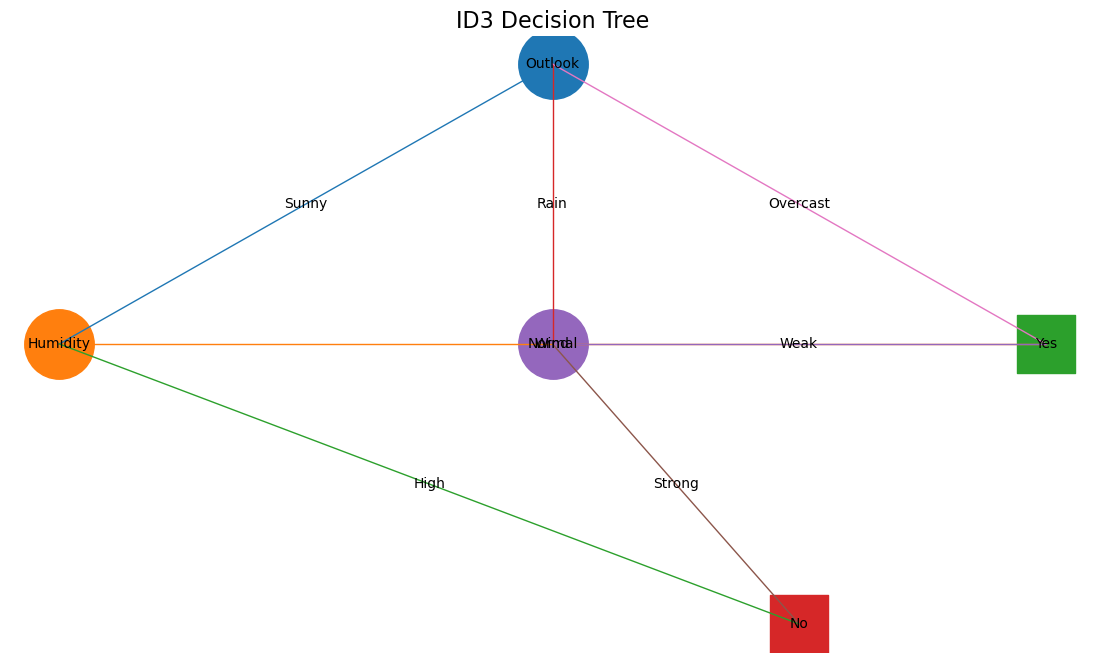

In [ ]:
import math
from collections import Counter
import matplotlib.pyplot as plt




data = [
    ["Sunny",    "Hot",  "High",   "Weak",   "No"],
    ["Sunny",    "Hot",  "High",   "Strong", "No"],
    ["Overcast", "Hot",  "High",   "Weak",   "Yes"],
    ["Rain",     "Mild", "High",   "Weak",   "Yes"],
    ["Rain",     "Cool", "Normal", "Weak",   "Yes"],
    ["Rain",     "Cool", "Normal", "Strong", "No"],
    ["Overcast", "Cool", "Normal", "Strong", "Yes"],
    ["Sunny",    "Mild", "High",   "Weak",   "No"],
    ["Sunny",    "Cool", "Normal", "Weak",   "Yes"],
    ["Rain",     "Mild", "Normal", "Weak",   "Yes"],
    ["Sunny",    "Mild", "Normal", "Strong", "Yes"],
    ["Overcast", "Mild", "High",   "Strong", "Yes"],
    ["Overcast", "Hot",  "Normal", "Weak",   "Yes"],
    ["Rain",     "Mild", "High",   "Strong", "No"]
]


features = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]


def entropy(labels):

    counts = Counter(labels)
    total = len(labels)

    ent = 0

    for count in counts.values():

        probability = count / total

        ent -= probability * math.log2(probability)

    return ent



def information_gain(X, y, feature_index):


    parent_entropy = entropy(y)


    values = set(
        row[feature_index]
        for row in X
    )

    weighted_entropy = 0

    for value in values:

        subset_y = []


        for i in range(len(X)):

            if X[i][feature_index] == value:

                subset_y.append(y[i])


        weight = len(subset_y) / len(y)

        subset_entropy = entropy(subset_y)

        weighted_entropy += weight * subset_entropy


    gain = parent_entropy - weighted_entropy

    return gain


def best_feature(X, y, feature_indices):

    best_gain = -1
    best_index = None

    for index in feature_indices:

        gain = information_gain(
            X,
            y,
            index
        )

        print(
            "Feature:",
            features[index],
            "Information Gain:",
            round(gain, 4)
        )

        if gain > best_gain:

            best_gain = gain
            best_index = index

    return best_index



def id3(X, y, feature_indices):



    if len(set(y)) == 1:

        return y[0]

    if len(feature_indices) == 0:

        return Counter(y).most_common(1)[0][0]


    best_index = best_feature(
        X,
        y,
        feature_indices
    )

    best_name = features[best_index]

    tree = {
        best_name: {}
    }

    values = set(
        row[best_index]
        for row in X
    )


    remaining_features = [
        index
        for index in feature_indices
        if index != best_index
    ]



    for value in values:

        subset_X = []
        subset_y = []

        for i in range(len(X)):

            if X[i][best_index] == value:

                subset_X.append(X[i])
                subset_y.append(y[i])


        subtree = id3(
            subset_X,
            subset_y,
            remaining_features
        )


        tree[best_name][value] = subtree


    return tree



print("\nBuilding Decision Tree...\n")

feature_indices = list(
    range(len(features))
)

tree = id3(
    X,
    y,
    feature_indices
)



print("\nFinal Decision Tree:")
print(tree)




def predict(tree, sample):

    if not isinstance(tree, dict):

        return tree


    
    feature_name = list(tree.keys())[0]


    feature_index = features.index(
        feature_name
    )


  
    value = sample[feature_index]


    
    subtree = tree[feature_name][value]


   
    return predict(
        subtree,
        sample
    )


sample = [
    "Sunny",
    "Cool",
    "High",
    "Strong"
]

result = predict(
    tree,
    sample
)


print("\nNew Sample:")
print(sample)

print("Prediction:", result)


def get_positions(
    tree,
    x=0,
    y=0,
    positions=None,
    edges=None,
    parent=None,
    edge_label=None
):

    if positions is None:
        positions = {}

    if edges is None:
        edges = []

 
    node_id = id(tree)

    if not isinstance(tree, dict):

        positions[node_id] = (x, y)

        if parent is not None:

            edges.append(
                (
                    parent,
                    node_id,
                    edge_label
                )
            )

        return positions, edges

    feature_name = list(tree.keys())[0]

    node_id = id(tree)

    positions[node_id] = (x, y)

    if parent is not None:

        edges.append(
            (
                parent,
                node_id,
                edge_label
            )
        )


    
    branches = tree[feature_name]

    number_of_branches = len(branches)

    spacing = 3

    start_x = (
        x
        - (number_of_branches - 1)
        * spacing
        / 2
    )


    for i, (value, subtree) in enumerate(
        branches.items()
    ):

        child_x = start_x + i * spacing
        child_y = y - 2

        get_positions(
            subtree,
            child_x,
            child_y,
            positions,
            edges,
            node_id,
            value
        )


    return positions, edges



def draw_tree(tree):

    positions, edges = get_positions(tree)


    plt.figure(
        figsize=(14, 8)
    )



    for parent, child, label in edges:

        x1, y1 = positions[parent]
        x2, y2 = positions[child]


        plt.plot(
            [x1, x2],
            [y1, y2],
            linewidth=1
        )


        middle_x = (x1 + x2) / 2
        middle_y = (y1 + y2) / 2


        plt.text(
            middle_x,
            middle_y,
            str(label),
            ha="center",
            va="center",
            fontsize=10
        )



    for node_id, (x, y) in positions.items():

    
        node = find_node(
            tree,
            node_id
        )


        if isinstance(node, dict):

            label = list(node.keys())[0]

        else:

            label = str(node)


  
        if isinstance(node, dict):

            plt.scatter(
                x,
                y,
                s=2500,
                marker="o"
            )

     
        else:

            plt.scatter(
                x,
                y,
                s=1800,
                marker="s"
            )


        plt.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=10
        )


    plt.title(
        "ID3 Decision Tree",
        fontsize=16
    )

    plt.axis("off")

    plt.show()



def find_node(tree, target_id):

    if id(tree) == target_id:

        return tree


    if isinstance(tree, dict):

        for subtree in tree.values():

            if isinstance(subtree, dict):

                result = find_node(
                    subtree,
                    target_id
                )

                if result is not None:

                    return result

            elif isinstance(subtree, str):

                if id(subtree) == target_id:

                    return subtree


    return None



draw_tree(tree)